In [ ]:
# Set the matplotlib backend so that figures can be saved in the background
# Import the necessary packages
import os
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from imutils import paths
import argparse
import pickle
import h5py

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense


LABELS = set(["Black spot", "canker", "greening","healthy","melanose","Scab"])
# Create the list of images in our dataset directory, then initialize the list of data (i.e., images) and class images to LABELs
dataset='/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus'
print("[INFO] loading images...")
imagePaths = list(paths.list_images(dataset))
print(imagePaths)
data = []
labels = []
# Loop over the image paths
for imagePath in imagePaths:
    # Extract the class label from the filename
    label = imagePath.split(os.path.sep)[-2]
    # If the label of the current image is not part of of the labels
    # that is of interest, then ignore the image
    if label not in LABELS:
        continue
    # Load the image, convert it to RGB channel ordering, and resize it into a fixed 224x224 pixels, ignoring aspect ratio
    image = cv2.imread(imagePath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    #cv2.imshow("image",image)
    # Update the data and labels lists, respectively
    data.append(image)
    labels.append(str(label))

# Convert the data and labels to NumPy arrays
data = np.array(data)
labels = np.array(labels)
print(labels)

# Perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# Partition the data into training and testing splits using 75% of the data for training and the remaining 25% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
    test_size=0.25, stratify=labels, random_state=42)

train_datagen = ImageDataGenerator(
    rescale=1./255,            # normalize pixel values between 0 and 1
    rotation_range=40,         # randomly rotate images
    width_shift_range=0.2,     # randomly shift images horizontally
    height_shift_range=0.2,    # randomly shift images vertically
    shear_range=0.2,           # randomly apply shearing transformations
    zoom_range=0.2,            # randomly zoom in or out on images
    horizontal_flip=True,      # randomly flip images horizontally
    fill_mode='nearest'        # fill newly created pixels near the borders with the nearest pixel values
)
valid_datagen = ImageDataGenerator(rescale=1/255.0)

model = Sequential([
    Conv2D(filters=16, kernel_size=(3, 3), input_shape=(224, 224, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2), padding='same'),
    Conv2D(filters=16, kernel_size=(3, 3), input_shape=(224, 224, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2), padding='same'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')]
)
epoch=10


history = model.fit(
        x=train_datagen.flow(trainX, trainY, batch_size=64),
        steps_per_epoch=len(trainX) // 64,
        validation_data=valid_datagen.flow(testX, testY),
        validation_steps=len(testX) // 64,
        epochs=epoch)



print("[INFO] evaluating network...")
predictions = model.predict(x=testX.astype("float32"), batch_size=64)
print(classification_report(testY.argmax(axis=1),
    predictions.argmax(axis=1), target_names=lb.classes_))

# confusion matrix
print("Confusion matrix")
print(confusion_matrix(testY.argmax(axis=1),
    predictions.argmax(axis=1)))


cm= confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')

## Display the visualization of the Confusion Matrix.
plt.savefig("Confusion_matrix.png")

# plot the training loss and accuracy
N = epoch
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
#plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
#plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.savefig("training.png")


# serialize the model to disk
print("[INFO] serializing network...")
model.save("model1.h5")

# serialize the label binarizer to disk
pkl_filename = "Pickle_model1.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(lb, file)

[INFO] loading images...
['/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (114).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (163).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (161).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (164).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (165).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (121).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (162).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (167).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves/greening/g (169).png', '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leav

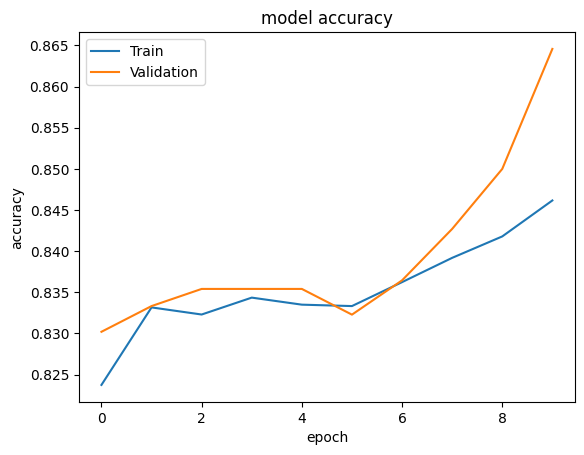

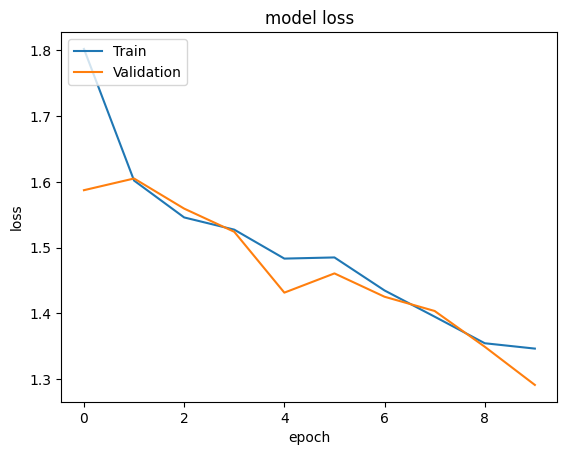

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

[INFO] loading model and label binarizer..
1/1 [==============================] - 0s 147ms/step


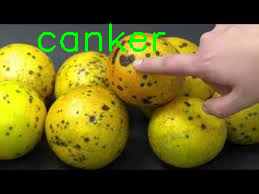

In [ ]:
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import load_model
from collections import deque
import numpy as np
import argparse
import pickle
import cv2

print("[INFO] loading model and label binarizer..")
model = load_model('/content/model1.h5')
lb = pickle.loads(open('/content/Pickle_model1.pkl',"rb").read())
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Fruits/Black spot/citrus fruit black spot12.jpg")

output = img.copy()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img , (224,224)).astype("float32")
preds = model.predict(np.expand_dims(img,axis = 0))[0]

i = np.argmax(preds)
label = lb.classes_[i]
text = "{}".format(label)

cv2.putText(output,text,(35,50), cv2.FONT_HERSHEY_SIMPLEX, 1.25, (0,255,0),2)
cv2_imshow(output)
cv2.waitKey(0)
cv2.destroyAllWindows()